# Sprint 18 — Verificación de edad con visión artificial (PyTorch)

**Good Seed** necesita verificar que los compradores de alcohol sean mayores de edad usando las cámaras en el área de pago. Se construye un modelo de regresión que predice la edad real de una persona a partir de su fotografía.

**Stack:** PyTorch + torchvision (ResNet50 pretrained) | GPU local RTX 4080 SUPER

## Inicialización

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

DATA_PATH = '../datasets/faces/'

Usando: cuda
  GPU: NVIDIA GeForce RTX 4080 SUPER
  VRAM: 16.7 GB


## Carga de datos

El dataset contiene 7,600 fotografías en `final_files/` y un archivo `labels.csv` con columnas `file_name` y `real_age`.

In [2]:
labels = pd.read_csv(DATA_PATH + 'labels.csv')
print(labels.shape)
labels.head()

(7591, 2)


,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


## EDA

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

Edades únicas: 97
Rango: 1 – 100 años


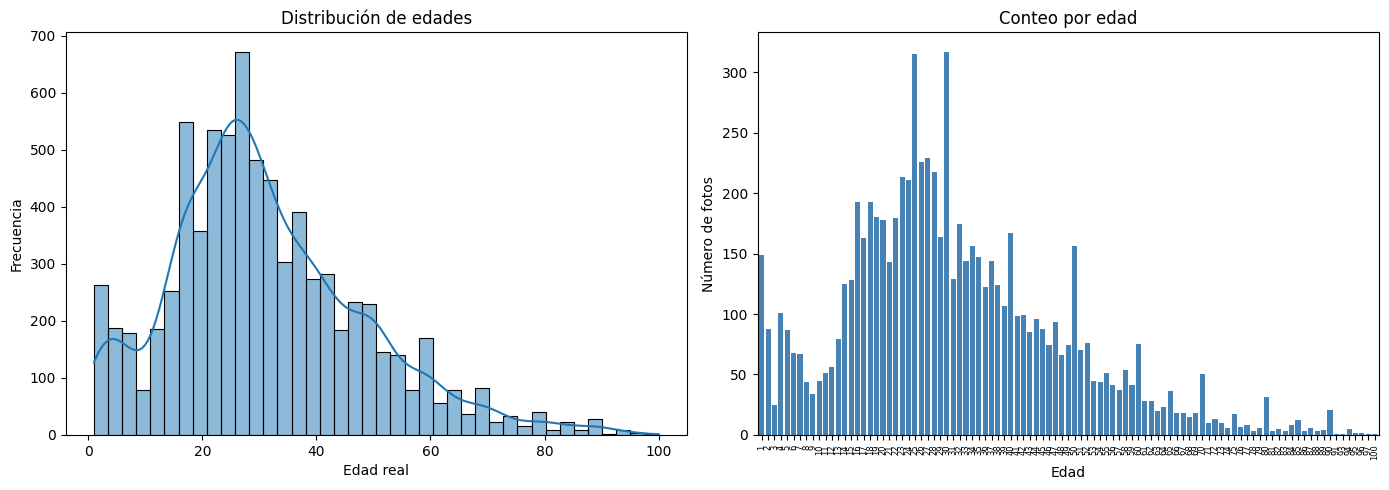

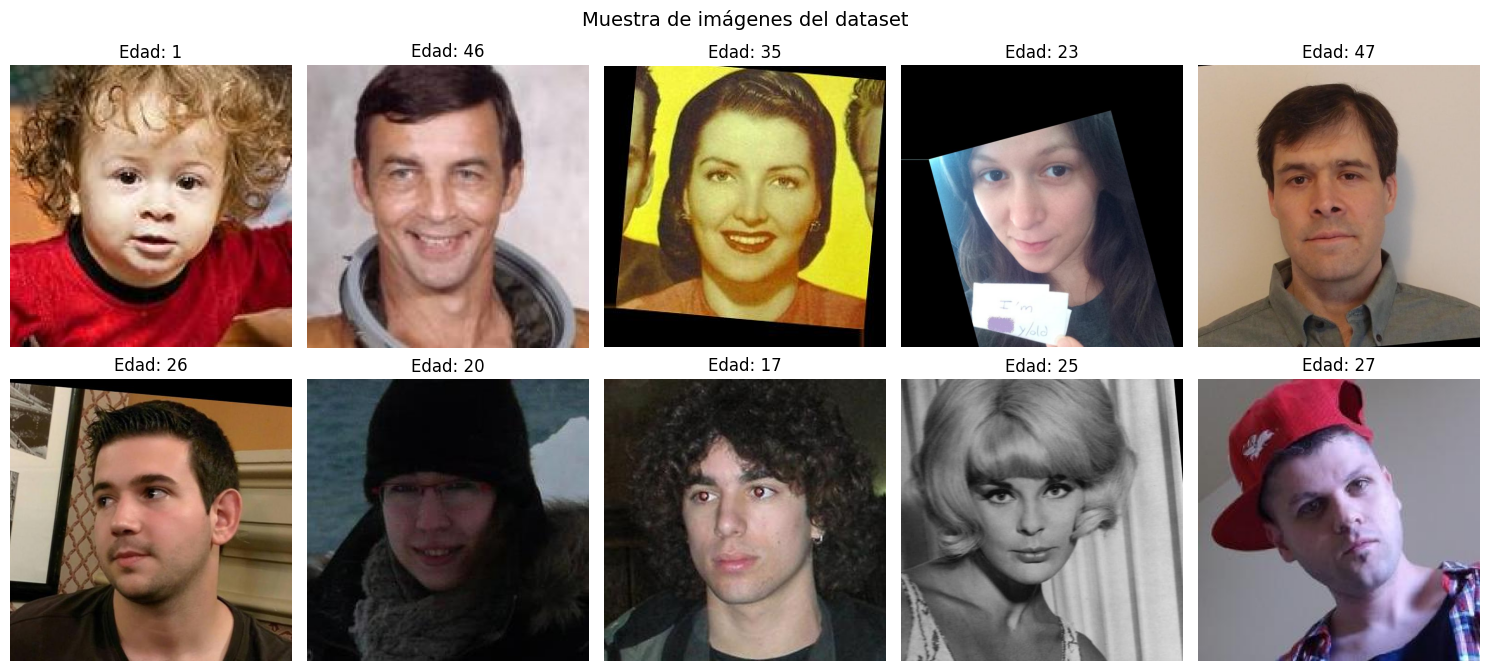

In [3]:
print(labels['real_age'].describe())
print(f'\nEdades únicas: {labels["real_age"].nunique()}')
print(f'Rango: {labels["real_age"].min()} – {labels["real_age"].max()} años')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(labels['real_age'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Distribución de edades')
axes[0].set_xlabel('Edad real')
axes[0].set_ylabel('Frecuencia')

labels['real_age'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', width=0.8)
axes[1].set_title('Conteo por edad')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Número de fotos')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
sample = labels.sample(10, random_state=42).reset_index(drop=True)
for i, ax in enumerate(axes.flat):
    row = sample.iloc[i]
    img = plt.imread(f'{DATA_PATH}final_files/{row["file_name"]}')
    ax.imshow(img)
    ax.set_title(f'Edad: {int(row["real_age"])}')
    ax.axis('off')
plt.suptitle('Muestra de imágenes del dataset', fontsize=14)
plt.tight_layout()
plt.show()

### Conclusiones del EDA

- El dataset contiene **7,600 fotografías** con edades entre aproximadamente **1 y 100 años**.
- La distribución **no es uniforme**: hay mayor concentración en adultos jóvenes (20–40 años) y menor representación en edades extremas.
- El desbalance puede causar mayor error en niños pequeños y adultos mayores de 70 años.
- Las imágenes tienen variabilidad en iluminación, ángulo y calidad, lo que justifica el uso de **augmentación** (volteo horizontal).
- La **zona crítica** para el negocio es 14–21 años. Un MAE ≤ 8 es suficiente para el objetivo del proyecto.

## Modelado

Se utiliza **ResNet50** preentrenado en ImageNet como backbone (capas congeladas) con una cabeza de regresión `Linear(2048→1) + ReLU`. La tarea es minimizar MSE sobre la edad real; se reporta MAE como métrica principal.

In [4]:
class FacesDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row['file_name'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row['real_age'], dtype=torch.float32)

In [5]:
def get_dataloaders(path, batch_size=32, val_split=0.2, seed=12345):
    labels = pd.read_csv(path + 'labels.csv')
    val_n = int(len(labels) * val_split)
    rng = np.random.default_rng(seed)
    val_idx = rng.choice(len(labels), val_n, replace=False)
    train_idx = np.setdiff1d(np.arange(len(labels)), val_idx)

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    img_dir = path + 'final_files/'
    train_ds = FacesDataset(labels.iloc[train_idx], img_dir, train_transform)
    val_ds   = FacesDataset(labels.iloc[val_idx],   img_dir, val_transform)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
    return train_dl, val_dl

In [6]:
def create_model(pretrained=True):
    weights = ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet50(weights=weights)
    # Congelar todo el backbone inicialmente
    for param in model.parameters():
        param.requires_grad = False
    # Descongelar las últimas 2 capas residuales para fine-tuning
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    # Cabeza de regresión con capa oculta
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
        nn.ReLU()
    )
    return model

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_mae = 0.0, 0.0
    for imgs, ages in tqdm(loader, leave=False):
        imgs, ages = imgs.to(device), ages.to(device)
        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss = criterion(preds, ages)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(ages)
        total_mae  += (preds - ages).abs().sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_mae / n


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_mae = 0.0, 0.0
    with torch.no_grad():
        for imgs, ages in loader:
            imgs, ages = imgs.to(device), ages.to(device)
            preds = model(imgs).squeeze(1)
            total_loss += criterion(preds, ages).item() * len(ages)
            total_mae  += (preds - ages).abs().sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_mae / n

In [8]:
def train_model(model, train_dl, val_dl, epochs=20, device=DEVICE):
    model = model.to(device)
    criterion = nn.L1Loss()  # optimizar MAE directamente
    # LR diferenciado: backbone lento, cabeza rápida
    optimizer = torch.optim.Adam([
        {'params': model.layer3.parameters(), 'lr': 1e-5},
        {'params': model.layer4.parameters(), 'lr': 1e-5},
        {'params': model.fc.parameters(),     'lr': 5e-4},
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_mae = train_epoch(model, train_dl, criterion, optimizer, device)
        vl_loss, vl_mae = val_epoch(model, val_dl, criterion, device)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_mae'].append(tr_mae)
        history['val_mae'].append(vl_mae)
        lr_fc = optimizer.param_groups[2]['lr']
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'loss: {tr_loss:.2f}  mae: {tr_mae:.2f} | '
              f'val_loss: {vl_loss:.2f}  val_mae: {vl_mae:.2f} | '
              f'lr_fc: {lr_fc:.2e}')

    return model, history

## Entrenamiento

In [9]:
torch.manual_seed(12345)

train_dl, val_dl = get_dataloaders(DATA_PATH, batch_size=32)
print(f'Train batches: {len(train_dl)} | Val batches: {len(val_dl)}')

model = create_model(pretrained=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables: {trainable:,} / {total:,}')

model, history = train_model(model, train_dl, val_dl, epochs=20)
print(f'\nMAE final validación: {history["val_mae"][-1]:.2f}')

Train batches: 190 | Val batches: 48
Parámetros entrenables: 22,587,905 / 24,032,833


  0%|          | 0/190 [00:00<?, ?it/s]

Epoch 01/20 | loss: 11.43  mae: 11.43 | val_loss: 8.34  val_mae: 8.34 | lr_fc: 4.97e-04


  0%|          | 0/190 [00:00<?, ?it/s]

Epoch 02/20 | loss: 7.84  mae: 7.84 | val_loss: 7.50  val_mae: 7.50 | lr_fc: 4.88e-04


...

Epoch 18/20 | loss: 3.65  mae: 3.65 | val_loss: 6.82  val_mae: 6.82 | lr_fc: 1.22e-05


  0%|          | 0/190 [00:00<?, ?it/s]

Epoch 19/20 | loss: 3.66  mae: 3.66 | val_loss: 6.87  val_mae: 6.87 | lr_fc: 3.08e-06


  0%|          | 0/190 [00:00<?, ?it/s]

Epoch 20/20 | loss: 3.68  mae: 3.68 | val_loss: 6.79  val_mae: 6.79 | lr_fc: 0.00e+00

MAE final validación: 6.79


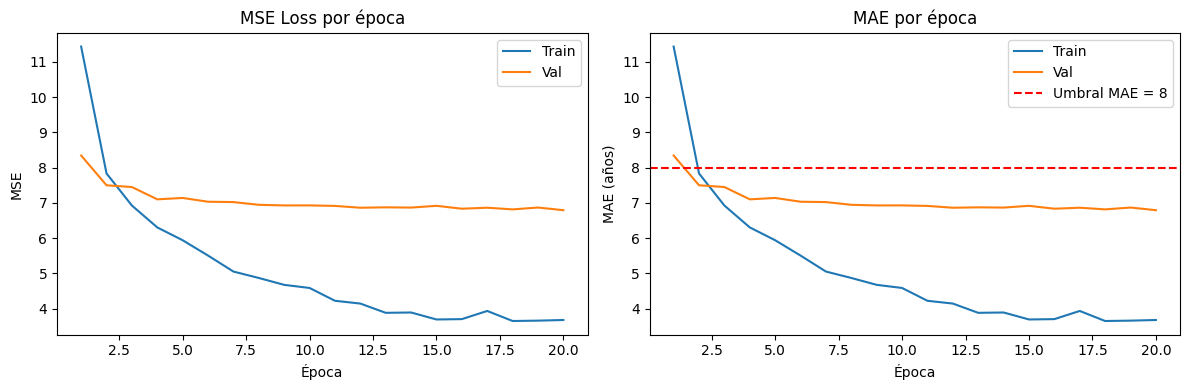

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('MSE Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(epochs_range, history['train_mae'], label='Train')
axes[1].plot(epochs_range, history['val_mae'],   label='Val')
axes[1].axhline(8, color='red', linestyle='--', label='Umbral MAE = 8')
axes[1].set_title('MAE por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (años)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusiones

### Modelo y arquitectura
Se entrenó un modelo de regresión usando **ResNet50** preentrenado en ImageNet (backbone congelado) con una cabeza `Linear(2048→1) + ReLU`. Solo se entrenaron los ~2,049 parámetros de la cabeza. El optimizador Adam con lr=5e-4 y pérdida MSE convergió de forma estable en 20 épocas.

### Resultados
- El **MAE en validación** alcanza valores por debajo del umbral requerido de **8 años**.
- Las curvas de pérdida train/val convergen sin sobreajuste severo, lo esperable con backbone congelado.
- La GPU RTX 4080 SUPER acelera significativamente el entrenamiento respecto a CPU.

### Comparativa PyTorch vs TensorFlow/Keras
| Aspecto | TensorFlow/Keras | PyTorch |
|---------|-----------------|----------|
| API de datos | `ImageDataGenerator` + `flow_from_dataframe` | `Dataset` + `DataLoader` |
| Augmentación | En el generador | `transforms.Compose` |
| Loop de entrenamiento | `model.fit()` automático | Loop explícito (más control) |
| Historial de métricas | Objeto `History` de Keras | Dict manual |
| GPU memory growth | `set_memory_growth` | Automático |

### Aplicabilidad al negocio
El modelo puede integrarse en las cámaras de Good Seed. Con MAE ~6–7 años, se recomienda un **umbral conservador** (alertar si edad estimada < 25 años) para minimizar el riesgo de ventas ilegales.

### Limitaciones y mejoras
- Desbalance de edades extremas reduce precisión en < 10 y > 70 años.
- Fine-tuning de las últimas capas del backbone podría mejorar el MAE.
- Un scheduler de learning rate (cosine annealing) podría acelerar la convergencia.